In [1]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [2]:
post_opto = ['BS_86','BS_119','BS_123','BS_128','BS_131','BS_163','BS_174']
post_control =  ['BS_42','BS_108','BS_56','BS_72','BS_70','BS_87','AE_312']

all_animals = np.concatenate([post_opto, post_control])

In [4]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 3e.csv'))

In [5]:
df

,Unnamed: 0,animal,session,phase,condition,FR modulation
0,0,BS_119,BS_119_2_opto_AC.pickle,1,opto,2.079832
1,1,BS_119,BS_119_2_opto_AC.pickle,1,opto,6.615044
2,2,BS_119,BS_119_2_opto_AC.pickle,1,opto,2.334071
3,3,BS_119,BS_119_2_opto_AC.pickle,1,opto,2.842920
4,4,BS_119,BS_119_2_opto_AC.pickle,1,opto,2.669617
...,...,...,...,...,...,...
1198,1198,AE_312,AE_312_8_opto_control_AC.pickle,post expert,control,74.331337
1199,1199,AE_312,AE_312_8_opto_control_AC.pickle,post expert,control,2.303030
1200,1200,AE_312,AE_312_8_opto_control_AC.pickle,post expert,control,5.528942
1201,1201,AE_312,AE_312_8_opto_control_AC.pickle,post expert,control,1.796407


In [6]:
df_opto = df[df['condition']=='opto']
opto_animals = np.unique(df_opto['animal'])

FR_postearly_animal = []
FR_postlate_animal = []
FR_postexpert_animal = []
for animal in opto_animals:
    
    postearly_animal = []
    postlate_animal = []
    postexpert_animal = []
    for row in df_opto.iloc():
        if row['animal'] != animal:
            continue
        if row['phase'] == '1':
            postearly_animal.append(row['FR modulation'])
        if row['phase'] == '2':
            postlate_animal.append(row['FR modulation'])
        if row['phase'] == '3':
            postexpert_animal.append(row['FR modulation'])
    postearly_animal = np.array(postearly_animal)
    postlate_animal = np.array(postlate_animal)
    postexpert_animal = np.array(postexpert_animal)
    
    FR_postearly_animal.append(postearly_animal)
    FR_postlate_animal.append(postlate_animal)
    FR_postexpert_animal.append(postexpert_animal)

    

df_control = df[df['condition']=='control']
control_animals = np.unique(df_control['animal'])

FR_Control_postearly_animal = []
FR_Control_postlate_animal = []
FR_Control_postexpert_animal = []
for animal in control_animals:
    
    postearly_animal = []
    postlate_animal = []
    postexpert_animal = []
    for row in df_control.iloc():
        if row['animal'] != animal:
            continue
        if row['phase'] == 'post early':
            postearly_animal.append(row['FR modulation'])
        if row['phase'] == 'post late':
            postlate_animal.append(row['FR modulation'])
        if row['phase'] == 'post expert':
            postexpert_animal.append(row['FR modulation'])
    postearly_animal = np.array(postearly_animal)
    postlate_animal = np.array(postlate_animal)
    postexpert_animal = np.array(postexpert_animal)
    
    FR_Control_postearly_animal.append(postearly_animal)
    FR_Control_postlate_animal.append(postlate_animal)
    FR_Control_postexpert_animal.append(postexpert_animal)

In [7]:
mean_pc_NCR = []
sem_pc_NCR = []
for FRmods in [FR_postearly_animal,FR_postlate_animal,FR_postexpert_animal]:
    Mw,SEMw = ilep.bootstrap_Mw_SEMw(FRmods,n_frac=1,CR_NCR_thresh=opto_thresh)
    mean_pc_NCR.append(Mw)
    sem_pc_NCR.append(SEMw)

mean_pc_NCR_control = []
sem_pc_NCR_control = []
for FRmods in [FR_Control_postearly_animal,FR_Control_postlate_animal,FR_Control_postexpert_animal]:
    Mw,SEMw = ilep.bootstrap_Mw_SEMw(FRmods,n_frac=1,CR_NCR_thresh=control_thresh)
    mean_pc_NCR_control.append(Mw)
    sem_pc_NCR_control.append(SEMw)

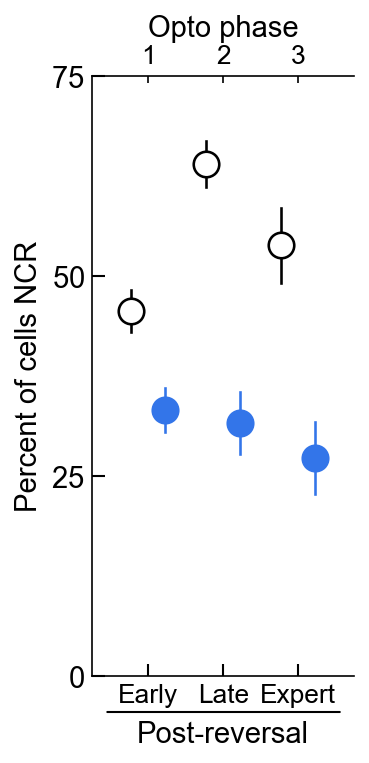

In [8]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

def statsbar(ax,barheight,xpoints,stemheights,text=None,lw=1):
    ymax = ax.get_ylim()[1]
    ymin = ax.get_ylim()[0]
    yrange = ymax-ymin
    ydist = 0.025*yrange
    
    ax.plot([xpoints[0]]*2,[stemheights[0]+ydist,barheight],lw=lw,color='k')
    ax.plot([xpoints[1]]*2,[stemheights[1]+ydist,barheight],lw=lw,color='k')
    ax.plot(xpoints,[barheight]*2,lw=lw,color='k')
    
    if not text is None:
        ax.text(np.mean(xpoints),barheight + ydist,text,horizontalalignment='center',verticalalignment='center')

fig,ax = make_axis_size(1.75, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0#0.1

################################################################################################################

wid = 0

offset=0.225
for idx,p in zip(range(6),[1,1,1]):
    
    ax.scatter([idx+wid+p*switch_offset-offset],(mean_pc_NCR_control[idx]),ec='k',fc='white',s=150,zorder=10,marker='o',lw=1.25)
    ax.plot([idx+wid+p*switch_offset-offset,idx+wid+p*switch_offset-offset],[(mean_pc_NCR_control[idx]-sem_pc_NCR_control[idx]),(mean_pc_NCR_control[idx]+sem_pc_NCR_control[idx])],color='k',lw=1.25,zorder=9)
    
    ax.scatter([idx+wid+p*switch_offset+offset],(mean_pc_NCR[idx]),c=LASER_COLOR,s=150,zorder=10,marker='o',lw=1.25)
    ax.plot([idx+wid+p*switch_offset+offset,idx+wid+p*switch_offset+offset],[(mean_pc_NCR[idx]-sem_pc_NCR[idx]),(mean_pc_NCR[idx]+sem_pc_NCR[idx])],color=LASER_COLOR,lw=1.25,zorder=9)
    
#ax.scatter([0,1,2,3,4,5],(mean_pc_NCR_passive)/100,fc='white',ec=GOOD_GREY,s=50,zorder=9,marker='o',lw=1)
# statsbar(ax,82,[1-wid-switch_offset,1+wid-switch_offset],stemheights=[passive_mean_pc_NCR[1]+passive_sem_pc_NCR[1] , mean_pc_NCR[1]+sem_pc_NCR[1]],text='*',lw=1)
# statsbar(ax,82,[4-wid+switch_offset,4+wid+switch_offset],stemheights=[passive_mean_pc_NCR[4]+passive_sem_pc_NCR[4] , mean_pc_NCR[4]+sem_pc_NCR[4]],text='****',lw=1)
# statsbar(ax,70,[5-wid+switch_offset,5+wid+switch_offset],stemheights=[passive_mean_pc_NCR[5]+passive_sem_pc_NCR[5] , mean_pc_NCR[5]+sem_pc_NCR[5]],text='****',lw=1)

################################################################################################################

labels = ['Early','Late','Expert']

ylab = ax.set_ylabel('Percent of cells NCR')
ax.set_ylim([0,75])
ax.set_yticks([0,25,50,75])
              
ax.set_xlim([-0.75-switch_offset,2.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset])
ax.set_xticklabels(labels)
# ax.set_xlabel('Opto phase')

sec_x = ax.secondary_xaxis('top')
sec_x.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset])
sec_x.set_xticklabels(['1','2','3'])
sxlab = sec_x.set_xlabel('Opto phase')

# xtick_pos_pre = ax.get_xticks()[1]
# xtick_pos_post = ax.get_xticks()[4]
# Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
# t1 = ax.text(xtick_pos_pre, Yval, 'Pre', ha='center', va='bottom', fontsize=stdfont,color='k')
# t2 = ax.text(xtick_pos_post, Yval, 'Post', ha='center', va='bottom',  fontsize=stdfont,color='k')
# ax.annotate('', xy=(0.03, -stdyfrac), xycoords='axes fraction', xytext=(0.49, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
# ax.annotate('', xy=(0.53, -stdyfrac), xycoords='axes fraction', xytext=(0.99, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))


stdyfrac = 0.06
xtick_pos_pre = ax.get_xticks()[1]
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
t1 = ax.text(xtick_pos_pre, Yval, 'Post-reversal', ha='center', va='bottom', fontsize=stdfont,color='k')
ax.annotate('', xy=(0.0425, -stdyfrac), xycoords='axes fraction', xytext=(0.96, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label,sec_x.xaxis.label,t1] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in ax.get_xticklabels() + sec_x.get_xticklabels():
    item.set_fontsize(stdfont*0.9)
    pass

# ax.scatter([], [], ec=PASSIVE_COLOR,fc='white', s=50,lw=1,marker='o',label='passive')
# ax.scatter([], [], ec=PASSIVE_COLOR,fc=PASSIVE_COLOR, s=50,lw=1,marker='o',label='behaving')
# ax.legend(frameon=False,loc=(0.5,0.1),fontsize=14)

### Log
# Y = 10**np.mean(np.log10(ax.get_ylim()))
# t = ax.text(2.5,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
# ax.plot([2.5]*2,[ax.get_ylim()[0],Y*0.45],lw=1,color=SWITCH_COLOR)
# ax.plot([2.5]*2,[ax.get_ylim()[1],Y/0.45],lw=1,color=SWITCH_COLOR)

### Linear
# Y = np.mean(ax.get_ylim())
# t = ax.text(2.5,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
# ax.plot([2.5]*2,[ax.get_ylim()[0],Y-np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)
# ax.plot([2.5]*2,[ax.get_ylim()[1],Y+np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)

artists = [ylab,t1,sec_x]
# fig.savefig(os.path.join('..','..','Figures','Figure 3e.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [9]:
Xs = [FR_postearly_animal, FR_postlate_animal, FR_postexpert_animal]
Ys = [FR_Control_postearly_animal, FR_Control_postlate_animal, FR_Control_postexpert_animal]

pvals = [np.nan]*3
for idx,(X,Y) in enumerate(zip(Xs,Ys)):
    X = np.array(X,dtype='object')
    Y = np.array(Y,dtype='object')
    pvals[idx] = ilep.bootstrap_pc_NCR_test(X,Y,B=25000,CR_NCR_thresh=[opto_thresh,control_thresh])
    print(pvals[idx])

0.0016000000000000458
0.0
8.000000000008001e-05
